Best Model: Logistic Regression
Best Score: 0.9666666666666667


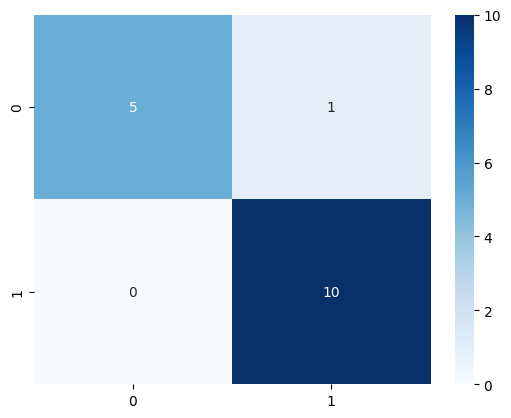

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.91      1.00      0.95        10

    accuracy                           0.94        16
   macro avg       0.95      0.92      0.93        16
weighted avg       0.94      0.94      0.94        16



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv('dataset_part_2.csv')
X = pd.get_dummies(df[['Orbit', 'Launch site', 'Payload mass', 'Launch outcome']])
Y = df['Class'].to_numpy()

transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

parameters_lr = {'C': [0.01, 0.1, 1]}
lr = LogisticRegression()
grid_search_lr = GridSearchCV(lr, parameters_lr, cv=3)
grid_search_lr.fit(X_train, Y_train)

parameters_svm = {'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': np.logspace(-3, 3, 5)}
svm = SVC()
grid_search_svm = GridSearchCV(svm, parameters_svm, cv=3)
grid_search_svm.fit(X_train, Y_train)

parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)]}
tree = DecisionTreeClassifier()
grid_search_tree = GridSearchCV(tree, parameters_tree, cv=3)
grid_search_tree.fit(X_train, Y_train)

parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1, 2]}
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn, parameters_knn, cv=3)
grid_search_knn.fit(X_train, Y_train)

models = {'Logistic Regression': grid_search_lr, 'SVM': grid_search_svm, 'Decision Tree': grid_search_tree, 'KNN': grid_search_knn}
best_model_name = max(models, key=lambda x: models[x].best_score_)
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best Score: {best_model.best_score_}")

yhat = best_model.predict(X_test)
cm = confusion_matrix(Y_test, yhat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

print(classification_report(Y_test, yhat))